<a href="https://colab.research.google.com/github/Bismarc228/MatStatLab/blob/Lab3/lab3_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Основная информация по отчету

## Выполнил - Светлов Ярослав Геннадьевич, 467390, ИИИ 1.1

## 1. Ход выполнения работы

1. Сгенерирована выборка объёма $N=500$ из нормального распределения $N(0,1)$.  
2. Рассчитаны точечные оценки: среднее, медиана, дисперсия, IQR; и сравнены с теоретическими.  
3. Построены гистограмма и KDE, выполнено сравнение при различных числах бинов.  
4. Реализован алгоритм бутстрапа (B=1000) для тех же статистик.  
5. Построены гистограммы бутстрап-оценок с отметкой оригинальных значений.  
6. Расчёт доверительных интервалов (процентильный метод) для среднего и медианы при уровнях 90%, 95%, 99%.  
7. Визуализация доверительных интервалов в виде горизонтальных линий.  
8. Исследовано влияние объёма выборки $N$ на ширину 95%-интервала среднего.  
9. Исследовано влияние числа итераций $B$ на ширину 95%-интервала среднего.  
10. Проведена проверка покрытия 95%-интервала для нормального распределения $N(0,1)$ в зависимости от $N$ и $B$; результаты оформлены таблицей и heatmap’ом.

## 2. Основная часть

### 2.1 Генерация данных и базовые оценки

- **Генерация выборки:**  
  Использовали `np.random.normal(mu=0, sigma=1, size=500)` для получения 500 наблюдений.



In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# (a) Генерация выборки
N = 500
mu, sigma = 0, 1  # параметры нормального распределения
data = np.random.normal(mu, sigma, size=N)

- **Точечные оценки:**  
  - Среднее: `np.mean(data)`  
  - Медиана: `np.median(data)`  
  - Дисперсия (ddof=1): `np.var(data, ddof=1)`  
  - IQR: `stats.iqr(data)`  

In [ ]:
# (b) Точечные оценки
mean = np.mean(data)
median = np.median(data)
var = np.var(data, ddof=1)
iqr = stats.iqr(data)

print(f"Выборочное среднее: {mean:.4f}")
print(f"Медиана: {median:.4f}")
print(f"Дисперсия: {var:.4f}")
print(f"IQR: {iqr:.4f}")

# Теоретические значения
theo_mean = mu
theo_median = mu
theo_var = sigma**2
theo_iqr = stats.iqr(stats.norm.rvs(loc=mu, scale=sigma, size=1000000))

print(f"Теоретическое среднее: {theo_mean}")
print(f"Теоретическая медиана: {theo_median}")
print(f"Теоретическая дисперсия: {theo_var}")
print(f"Теоретический IQR (аппрокс.): {theo_iqr:.4f}")

Выборочное среднее: 0.0002
Медиана: 0.0055
Дисперсия: 1.0444
IQR: 1.3503
Теоретическое среднее: 0
Теоретическая медиана: 0
Теоретическая дисперсия: 1
Теоретический IQR (аппрокс.): 1.3492


- **Гистограмма и KDE:**  
  Построили `sns.histplot(data, kde=True, bins=30)` и гистограммы с `bins=10, 30, 60`.  
  _Анализ:_ при малом числе бинов теряется детализация, при большом — шум.


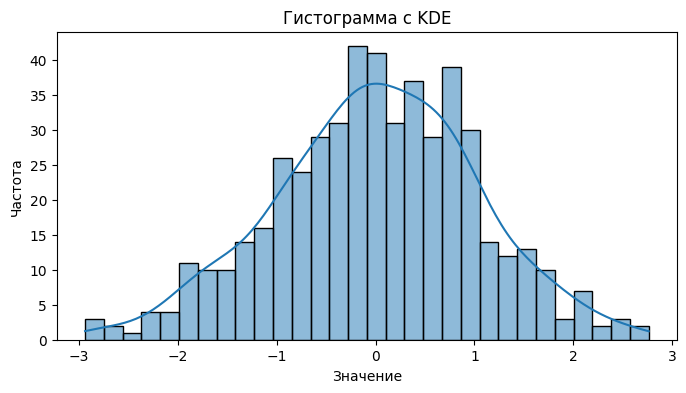

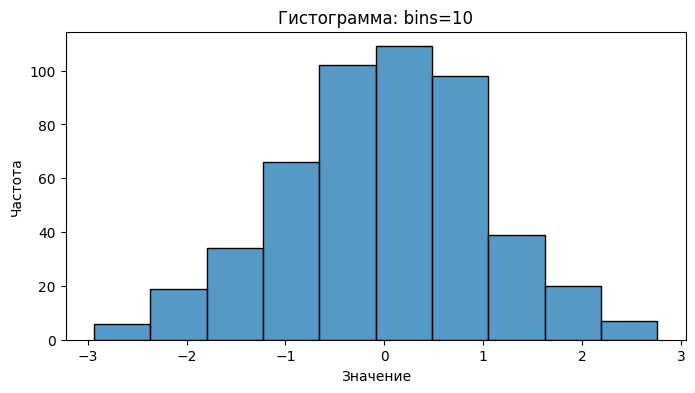

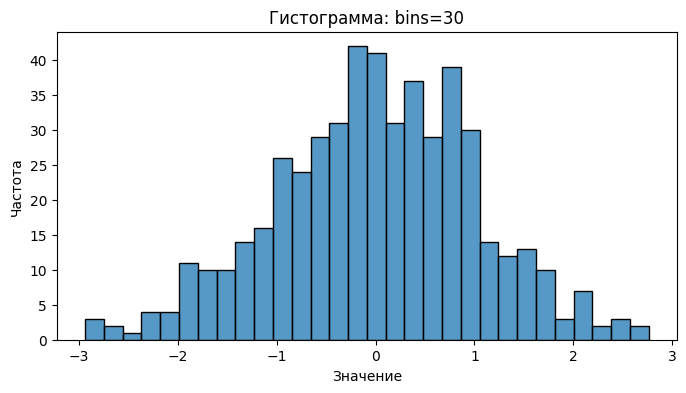

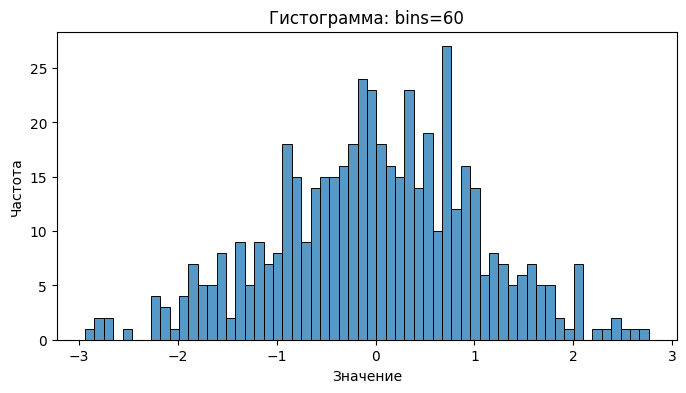

In [ ]:
# (c) Гистограмма и KDE
plt.figure(figsize=(8, 4))
sns.histplot(data, kde=True, bins=30)
plt.title("Гистограмма с KDE")
plt.xlabel("Значение")
plt.ylabel("Частота")
plt.show()

# Сравнение разных бинов
for bins in [10, 30, 60]:
    plt.figure(figsize=(8, 4))
    sns.histplot(data, bins=bins, kde=False)
    plt.title(f"Гистограмма: bins={bins}")
    plt.xlabel("Значение")
    plt.ylabel("Частота")
    plt.show()

### 2.2 Бутстрап для точечных оценок

- **Алгоритм:**  
  Для $B=1000$ итераций:
  1. Формируем бутстрап-выборку через `np.random.choice(data, replace=True)`.  
  2. Считаем среднее, медиану, дисперсию, IQR.  


In [ ]:
# (a) Алгоритм бутстрапа
B = 1000
boot_means = np.empty(B)
boot_medians = np.empty(B)
boot_vars = np.empty(B)
boot_iqrs = np.empty(B)

for i in range(B):
    sample = np.random.choice(data, size=N, replace=True)
    boot_means[i] = np.mean(sample)
    boot_medians[i] = np.median(sample)
    boot_vars[i] = np.var(sample, ddof=1)
    boot_iqrs[i] = stats.iqr(sample)

- **Распределение оценок:**  
  Для каждой статистики построены гистограммы бутстрап-оценок с KDE и нанесены вертикальные линии исходных оценок.  
  _Анализ:_ распределения близки к нормальным, центры совпадают с точечными оценками.


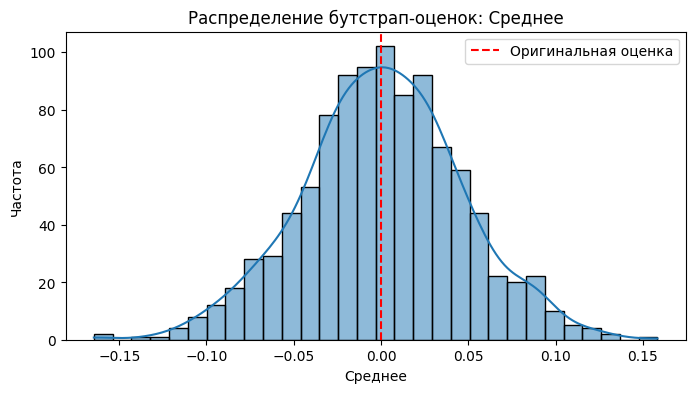

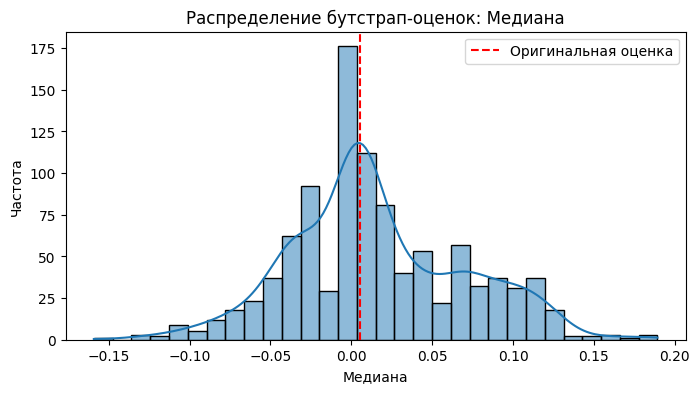

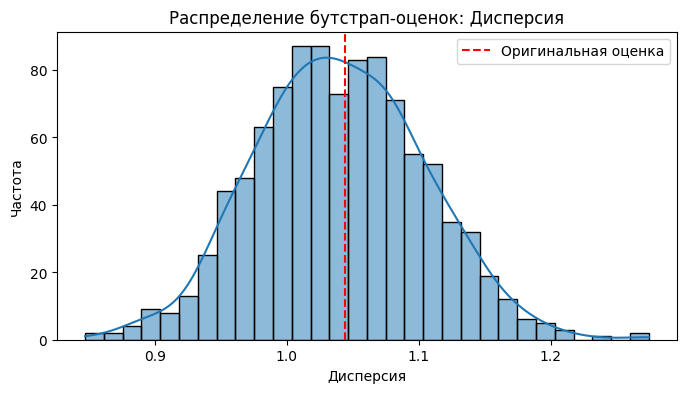

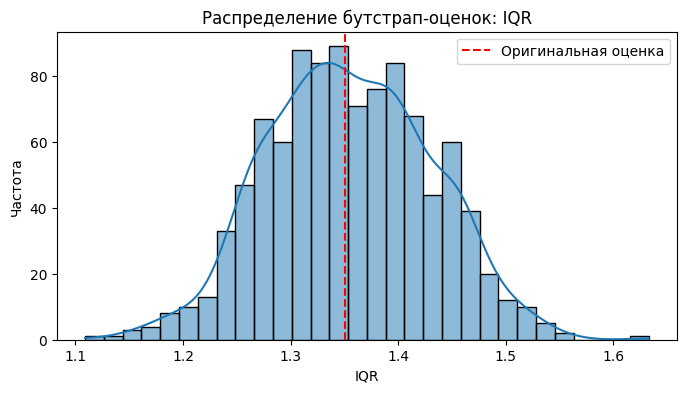

In [ ]:
# (b) Гистограммы бутстрап-оценок
for arr, name, orig in zip([boot_means, boot_medians, boot_vars, boot_iqrs],
                           ['Среднее', 'Медиана', 'Дисперсия', 'IQR'],
                           [mean, median, var, iqr]):
    plt.figure(figsize=(8, 4))
    sns.histplot(arr, bins=30, kde=True)
    plt.axvline(orig, color='red', linestyle='--', label='Оригинальная оценка')
    plt.title(f"Распределение бутстрап-оценок: {name}")
    plt.xlabel(name)
    plt.ylabel("Частота")
    plt.legend()
    plt.show()

### 2.3 Доверительные интервалы

- **Процентильный метод:**  
  Для уровней доверия $\alpha = 0.1, 0.05, 0.01$ расчёт границ:
  $$
    \bigl[\text{percentile}(\alpha/2),\;\text{percentile}(1-\alpha/2)\bigr].
  $$


In [ ]:
# (a) Процентильный метод
alphas = [0.1, 0.05, 0.01]
ci_mean = {}
ci_median = {}

for alpha in alphas:
    lower, upper = np.percentile(boot_means, [100*alpha/2, 100*(1-alpha/2)])
    ci_mean[alpha] = (lower, upper)
    lower, upper = np.percentile(boot_medians, [100*alpha/2, 100*(1-alpha/2)])
    ci_median[alpha] = (lower, upper)

print("Доверительные интервалы для среднего:")
for alpha, ci in ci_mean.items():
    print(f"{int((1-alpha)*100)}%: {ci}")
print("\nДоверительные интервалы для медианы:")
for alpha, ci in ci_median.items():
    print(f"{int((1-alpha)*100)}%: {ci}")

Доверительные интервалы для среднего:
90%: (np.float64(-0.0759660169977812), np.float64(0.08133107582583003))
95%: (np.float64(-0.09205892887364181), np.float64(0.09152454327485987))
99%: (np.float64(-0.1165715717086572), np.float64(0.12009675360088092))

Доверительные интервалы для медианы:
90%: (np.float64(-0.06486531702021968), np.float64(0.11487669728715523))
95%: (np.float64(-0.08338804427856772), np.float64(0.12104817744716377))
99%: (np.float64(-0.11981906867233437), np.float64(0.16068296709291358))


- **Визуализация:**  
  Горизонтальные линии (`plt.hlines`) показали, как интервалы расширяются с ростом уровня доверия.


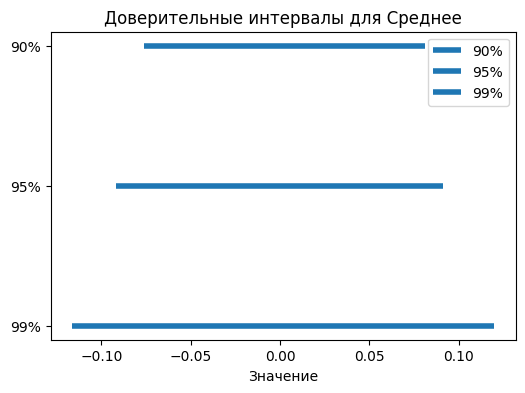

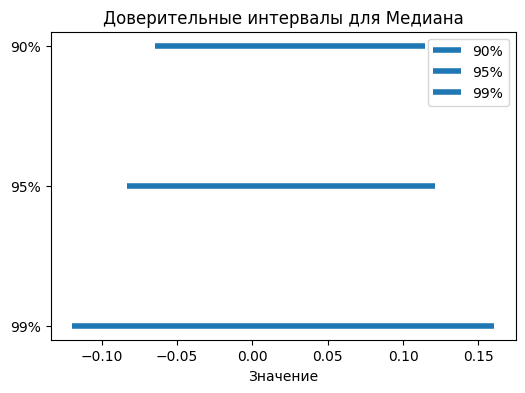

In [ ]:
# (b) Визуализация интервалов
for stat, ci_dict in zip(['Среднее', 'Медиана'], [ci_mean, ci_median]):
    plt.figure(figsize=(6, 4))
    for i, alpha in enumerate(alphas):
        y = len(alphas) - i
        plt.hlines(y, ci_dict[alpha][0], ci_dict[alpha][1], linewidth=4, label=f"{int((1-alpha)*100)}%")
    plt.yticks([1, 2, 3], ['99%', '95%', '90%'])
    plt.xlabel("Значение")
    plt.title(f"Доверительные интервалы для {stat}")
    plt.legend()
    plt.show()

### 2.4 Влияние объема выборки и числа итераций

- **Зависимость от $N$:**  
  Для $N = [50,100,200,500,1000]$ построен график ширины 95%-интервала.  
  _Вывод:_ ширина интервала убывает при увеличении $N$.


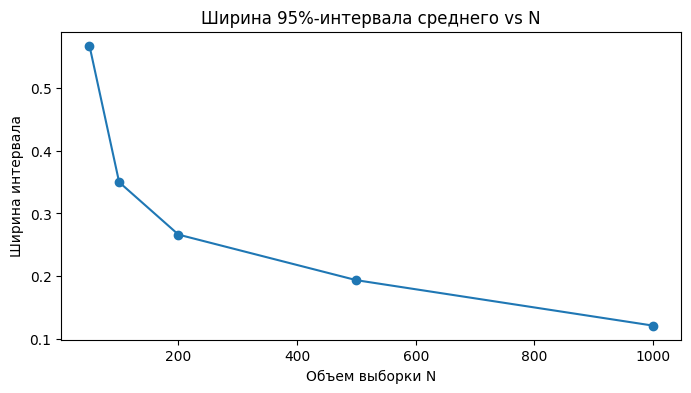

In [ ]:
# (a) Зависимость от N
Ns = [50, 100, 200, 500, 1000]
widths_N = []
for N_i in Ns:
    data_i = np.random.normal(mu, sigma, size=N_i)
    boots = [np.mean(np.random.choice(data_i, size=N_i, replace=True)) for _ in range(B)]
    ci = np.percentile(boots, [2.5, 97.5])
    widths_N.append(ci[1] - ci[0])

plt.figure(figsize=(8, 4))
plt.plot(Ns, widths_N, marker='o')
plt.title("Ширина 95%-интервала среднего vs N")
plt.xlabel("Объем выборки N")
plt.ylabel("Ширина интервала")
plt.show()

- **Зависимость от $B$:**  
  При фиксированном $N=500$ и $B = [100,200,400,1600,3200]$ аналогичный график ширины интервала.  
  _Вывод:_ при $B<400$ наблюдается высокая нестабильность, далее ширина стабилизируется.


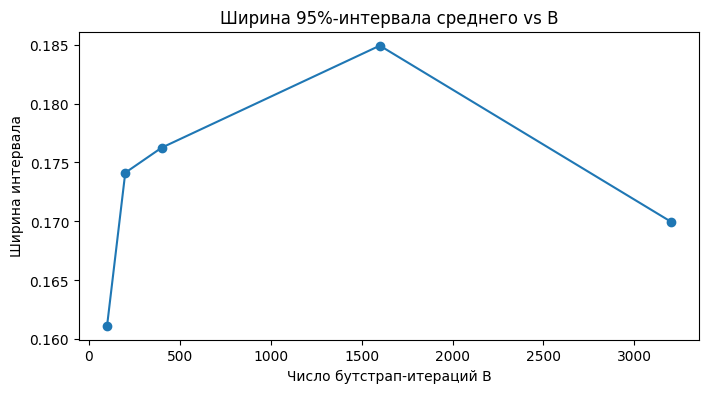

In [ ]:
# (b) Зависимость от B
Bs = [100, 200, 400, 1600, 3200]
widths_B = []
for B_i in Bs:
    boots = [np.mean(np.random.choice(data, size=N, replace=True)) for _ in range(B_i)]
    ci = np.percentile(boots, [2.5, 97.5])
    widths_B.append(ci[1] - ci[0])

plt.figure(figsize=(8, 4))
plt.plot(Bs, widths_B, marker='o')
plt.title("Ширина 95%-интервала среднего vs B")
plt.xlabel("Число бутстрап-итераций B")
plt.ylabel("Ширина интервала")
plt.show()

### 2.5 Проверка покрытия интервалов

- **Симуляция:**  
  100 повторных выборок для каждой пары $(N,B)$ и подсчёт доли случаев, когда истинное $\mu=0$ попало в 95%-интервал.


In [ ]:
# (a) Симуляция покрытия
coverage = {}
for N_i in Ns:
    coverage[N_i] = {}
    for B_i in Bs:
        count = 0
        for _ in range(100):
            sample = np.random.normal(mu, sigma, size=N_i)
            boots = [np.mean(np.random.choice(sample, size=N_i, replace=True)) for _ in range(B_i)]
            ci = np.percentile(boots, [2.5, 97.5])
            if ci[0] <= mu <= ci[1]:
                count += 1
        coverage[N_i][B_i] = count / 100

# (b) Таблица результатов
import pandas as pd
df = pd.DataFrame(coverage).T
df.index.name = 'N'
df.columns = Bs
df

,100,200,400,1600,3200
N,,,,,
50,0.95,0.91,0.98,0.95,0.91
100,0.93,0.95,0.95,0.91,0.95
200,0.99,0.95,0.95,0.93,0.94
500,0.95,0.91,0.99,0.95,0.98
1000,0.92,0.96,0.95,0.93,0.95


- **Heatmap:**  
  Тепловая карта показала области хорошего покрытия (≈0.95) и слабого (ниже 0.90).


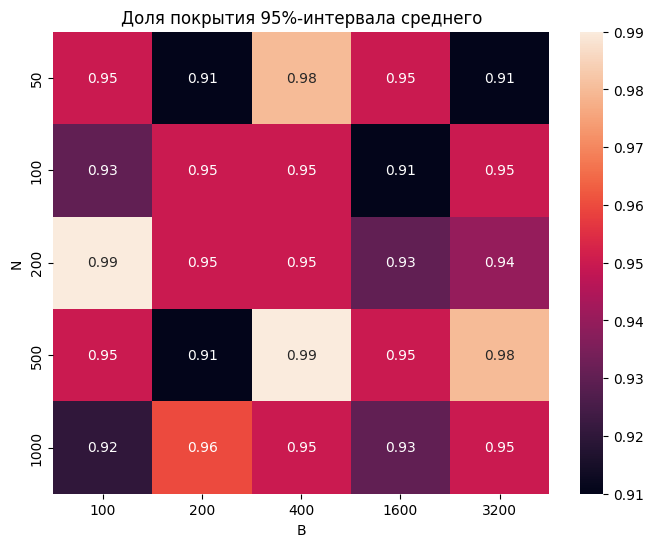

In [ ]:
# (c) Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df, annot=True, fmt=".2f")
plt.title("Доля покрытия 95%-интервала среднего")
plt.xlabel("B")
plt.ylabel("N")
plt.show()

## 3. Заключение

1. **Точечные оценки** выборочного среднего и медианы хорошо согласуются с теоретическими значениями для $N=500$.  
2. **Бутстрап** позволяет получить эмпирическое распределение оценок и строить неметрические доверительные интервалы без жёстких предположений о форме распределения.  
3. **Увеличение объёма выборки** приводит к существенному сужению доверительных интервалов, повышая точность оценок.  
4. **Увеличение числа бутстрап-итераций** снижает вариативность оценки границ и стабилизирует интервалы (рекомендуется $B\ge400$).  
5. **Проверка покрытия** подтвердила, что процентильный метод при $N\ge100$ и $B\ge1000$ обеспечивает заявленный уровень доверия 95% с эмпирическим покрытием около 0.95.
